# Модуль 3. Линейная алгебра как язык

Ноутбук к [модулю 3](https://drobyshevdev.github.io/lemma/modules/03-linear-algebra/).

Шесть сюжетов: косинусная близость, матрица как преобразование, регрессия через нормальное уравнение, ортогональность остатка, PCA руками и число обусловленности.

Никаких библиотек машинного обучения. Только `numpy` и `matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260803)
np.set_printoptions(precision=4, suppress=True)

plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Скалярное произведение как похожесть

Игрушечные «эмбеддинги»: три координаты — техника, юриспруденция, спорт. Значение координаты означает, насколько документ об этом.

In [2]:
docs = {
    "статья про нейросети":   np.array([9.0, 0.5, 0.2]),
    "заметка про нейросети":  np.array([2.7, 0.15, 0.06]),   # то же направление, короче втрое
    "договор поставки":       np.array([0.4, 8.0, 0.1]),
    "отчёт о матче":          np.array([0.2, 0.3, 7.0]),
}

query = np.array([1.0, 0.1, 0.0])       # запрос: техника

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

print(f"{'документ':<24} {'скалярное':>10} {'косинус':>9}")
for name, vec in docs.items():
    print(f"{name:<24} {query @ vec:>10.2f} {cosine(query, vec):>9.3f}")

документ                  скалярное   косинус
статья про нейросети           9.05     0.999
заметка про нейросети          2.72     0.999
договор поставки               1.20     0.149
отчёт о матче                  0.23     0.033


Смотрите на две первые строки. Статья и заметка — про одно и то же, направление у них одинаковое. Но по скалярному произведению статья втрое «релевантнее» просто потому, что вектор длиннее.

Косинус даёт им одинаковую близость, потому что делит на длину. Поэтому поиск по эмбеддингам считает косинус, а не скалярное произведение: иначе длинные документы выигрывали бы у коротких на пустом месте.

**Сломайте:** умножьте вектор договора на 10. Что станет со скалярным произведением и что с косинусом?

## 2. Матрица как преобразование

Не таблица чисел, а функция. Посмотрим, что она делает с единичным квадратом.

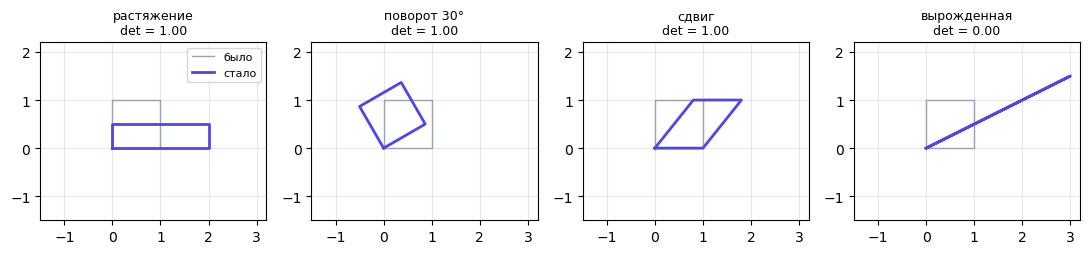

In [3]:
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]], dtype=float)

transforms = {
    "растяжение":  np.array([[2.0, 0.0], [0.0, 0.5]]),
    "поворот 30°": np.array([[np.cos(np.pi/6), -np.sin(np.pi/6)],
                             [np.sin(np.pi/6),  np.cos(np.pi/6)]]),
    "сдвиг":       np.array([[1.0, 0.8], [0.0, 1.0]]),
    "вырожденная": np.array([[1.0, 2.0], [0.5, 1.0]]),
}

fig, axes = plt.subplots(1, 4, figsize=(11, 2.8))
for ax, (name, A) in zip(axes, transforms.items()):
    out = A @ square
    ax.plot(square[0], square[1], color="#94a3b8", lw=1, label="было")
    ax.plot(out[0], out[1], color="#4f46e5", lw=2, label="стало")
    ax.set_title(f"{name}\ndet = {np.linalg.det(A):.2f}", fontsize=9)
    ax.set_aspect("equal")
    ax.set_xlim(-1.5, 3.2); ax.set_ylim(-1.5, 2.2)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Определитель — во сколько раз изменилась площадь. У последней матрицы он равен нулю: квадрат схлопнулся в отрезок. Двумерное пространство ушло в одномерное, и обратно его не вернуть — такая матрица не обратима.

Проверим утверждение из текста: результат — линейная комбинация столбцов.

In [4]:
A = np.array([[2.0, -1.0], [1.0, 3.0]])
x = np.array([3.0, 2.0])

print("A @ x                     =", A @ x)
print("x[0]*столбец0 + x[1]*столбец1 =", x[0] * A[:, 0] + x[1] * A[:, 1])

A @ x                     = [4. 9.]
x[0]*столбец0 + x[1]*столбец1 = [4. 9.]


## 3. Регрессия через нормальное уравнение

Сгенерируем данные с известными весами и восстановим их.

In [5]:
n, d = 200, 3
TRUE_W = np.array([1.5, -2.0, 0.7, 4.0])     # последний — свободный член

rng = np.random.default_rng(1)
X_raw = rng.normal(0, 1, size=(n, d))
X = np.hstack([X_raw, np.ones((n, 1))])      # столбец единиц под свободный член
y = X @ TRUE_W + rng.normal(0, 0.5, n)

# Нормальное уравнение буквально по формуле.
w_formula = np.linalg.inv(X.T @ X) @ X.T @ y

# То же самое, но без обращения матрицы: так и надо делать на практике.
w_lstsq = np.linalg.lstsq(X, y, rcond=None)[0]

print("истинные веса:  ", TRUE_W)
print("по формуле:     ", w_formula)
print("через lstsq:    ", w_lstsq)
print(f"\nрасхождение между способами: {np.abs(w_formula - w_lstsq).max():.2e}")

истинные веса:   [ 1.5 -2.   0.7  4. ]
по формуле:      [ 1.5111 -2.0071  0.6573  3.9181]
через lstsq:     [ 1.5111 -2.0071  0.6573  3.9181]

расхождение между способами: 1.89e-15


## 4. Остаток перпендикулярен признакам

Утверждение из текста: регрессия — это проекция, а значит остаток ортогонален каждому столбцу $X$. Это число, которое обязано быть нулём.

In [6]:
residual = y - X @ w_lstsq

print("скалярное произведение остатка с каждым столбцом X:")
print(X.T @ residual)
print(f"\nмаксимум по модулю: {np.abs(X.T @ residual).max():.2e}")
print("\nЭто машинный ноль. Не ноль — значит решена не та задача.")

скалярное произведение остатка с каждым столбцом X:
[-0. -0.  0.  0.]

максимум по модулю: 4.43e-13

Это машинный ноль. Не ноль — значит решена не та задача.


**Сломайте:** возьмите заведомо неверные веса `w_bad = w_lstsq + 0.1` и посчитайте то же произведение. Насколько оно перестанет быть нулём?

## 5. PCA руками

Пять строк: центрировать, ковариация, собственные векторы, отсортировать, взять первые.

In [7]:
rng = np.random.default_rng(5)
base = rng.normal(0, 1, size=(400, 2)) @ np.array([[3.0, 1.2], [0.0, 0.6]])
cloud = base + np.array([2.0, -1.0])

def pca(data):
    centred = data - data.mean(axis=0)
    cov = np.cov(centred, rowvar=False)
    values, vectors = np.linalg.eigh(cov)      # eigh: ковариация симметрична
    order = np.argsort(values)[::-1]           # по убыванию
    return values[order], vectors[:, order], centred

values, vectors, centred = pca(cloud)

print("собственные числа (дисперсии вдоль осей):", values)
print("доля объяснённой дисперсии:              ", values / values.sum())
print("первая главная компонента:               ", vectors[:, 0])

собственные числа (дисперсии вдоль осей): [9.6694 0.3174]
доля объяснённой дисперсии:               [0.9682 0.0318]
первая главная компонента:                [-0.9265 -0.3762]


Проверим, что это действительно направление максимального разброса. Переберём все направления и найдём лучшее вслепую.

In [8]:
angles = np.linspace(0, np.pi, 2000)
directions = np.stack([np.cos(angles), np.sin(angles)])
# ddof=1, как в np.cov: иначе числа разойдутся на множитель n/(n-1)
spread = (centred @ directions).var(axis=0, ddof=1)

best = directions[:, spread.argmax()]
print("перебором:      ", best)
print("через eigh:     ", vectors[:, 0] * np.sign(vectors[0, 0] * best[0]))
print(f"\nмаксимальная дисперсия перебором: {spread.max():.4f}")
print(f"наибольшее собственное число:      {values[0]:.4f}")

перебором:       [0.9268 0.3756]
через eigh:      [0.9265 0.3762]

максимальная дисперсия перебором: 9.6694
наибольшее собственное число:      9.6694


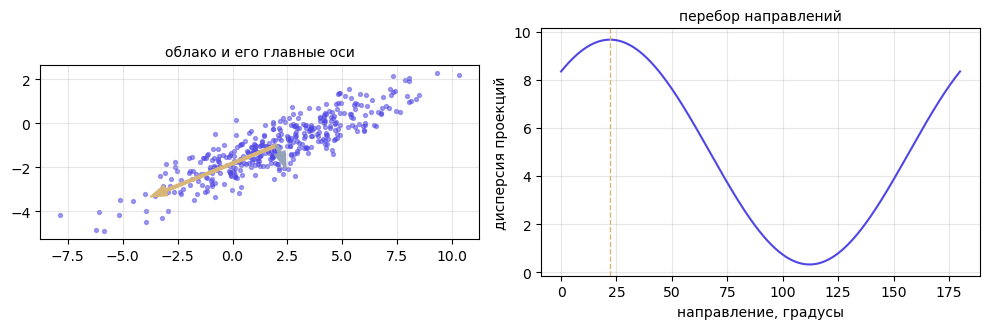

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

ax1.scatter(cloud[:, 0], cloud[:, 1], s=8, alpha=0.5, color="#4f46e5")
centre = cloud.mean(axis=0)
for i, colour in enumerate(["#d8b678", "#94a3b8"]):
    axis = vectors[:, i] * np.sqrt(values[i]) * 2
    ax1.annotate("", xy=centre + axis, xytext=centre,
                 arrowprops=dict(color=colour, width=2, headwidth=8))
ax1.set_aspect("equal")
ax1.set_title("облако и его главные оси", fontsize=10)

ax2.plot(np.degrees(angles), spread, color="#4f46e5")
ax2.axvline(np.degrees(angles[spread.argmax()]), color="#d8b678", ls="--", lw=1)
ax2.set_xlabel("направление, градусы")
ax2.set_ylabel("дисперсия проекций")
ax2.set_title("перебор направлений", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Число обусловленности и коллинеарность

Добавим признак, почти повторяющий другой, и посмотрим, что станет с весами.

In [10]:
rng = np.random.default_rng(11)
a = rng.normal(0, 1, 200)

print(f"{'дублирующий шум':>16} {'kappa':>12} {'веса двух связанных признаков':>34}")
for noise in [1.0, 0.1, 0.01, 0.001]:
    b = a + rng.normal(0, noise, 200)          # почти копия a
    Xc = np.stack([a, b, np.ones(200)], axis=1)
    yc = 3 * a + rng.normal(0, 0.3, 200)
    w = np.linalg.lstsq(Xc, yc, rcond=None)[0]
    kappa = np.linalg.cond(Xc.T @ Xc)
    print(f"{noise:>16} {kappa:>12.1f} {str(np.round(w[:2], 2)):>34}")

 дублирующий шум        kappa      веса двух связанных признаков
             1.0          7.9                        [3.04 0.01]
             0.1        311.0                        [2.85 0.17]
            0.01      33145.6                        [0.85 2.16]
           0.001    3763913.4                    [-27.15  30.18]


Истинная зависимость всё время одна: `y = 3a`. Но чем ближе `b` к `a`, тем сильнее веса разъезжаются в плюс и минус, компенсируя друг друга. Число обусловленности растёт на порядки.

Предсказания при этом остаются приличными — разъезжаются именно **веса**. Отсюда правило: на коллинеарных признаках вес не означает важность.

И это же число обусловленности определит, насколько тяжело будет градиентному спуску в модуле 4.

**Сломайте:** сделайте `b` точной копией `a`. Что вернёт `lstsq` и почему он вообще что-то вернёт, хотя решение не единственно?

## Итог

1. Косинус меряет направление, скалярное произведение — направление вместе с длиной.
2. Матрица — функция; определитель — во сколько раз меняется площадь; нулевой определитель означает потерю размерности.
3. Нормальное уравнение и `lstsq` дают один ответ, но `lstsq` не обращает матрицу.
4. Остаток регрессии ортогонален признакам с точностью до машинного нуля — это тест на правильность решения.
5. Первая главная компонента, найденная через `eigh`, совпадает с найденной перебором направлений.
6. Коллинеарность раздувает число обусловленности и разносит веса, не портя предсказаний.

Дальше — [модуль 4](https://drobyshevdev.github.io/lemma/programme/): градиент, шаг и то, что делать, когда точного решения нет.